In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/jobs.csv")

In [5]:
df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,Data Engineer 2,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/data-engine...,2023-12-17,Bloomington,United States,Mid senior,Onsite,"Overview\nThe Data Engineer develops, implemen...","Azure, SQL, NoSQL, SQL Server, Oracle, MongoDB..."
1,Staff Data Engineer,Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/staff-data-...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"Python, Snowflake, Airflow, Kubernetes, Docker..."
2,"Senior Data Engineer, Public Company",Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-data...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"Python, SQL, Snowflake, Airflow, Kubernetes, D..."
3,"Senior Data Engineer, Public Company",Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-data...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"TDD, Automation, Continuous delivery, Data eng..."
4,"Senior Systems Engineer, Azure Data Platform",Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-syst...,2023-12-17,Bloomington,United States,Mid senior,Hybrid,Overview\nWe are seeking a talented Azure Clou...,NaN


In [6]:
df.shape

(6025, 11)

In [7]:
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       6025 non-null   object
 1   company         6025 non-null   object
 2   job_location    6025 non-null   object
 3   job_link        6025 non-null   object
 4   first_seen      6025 non-null   object
 5   search_city     6025 non-null   object
 6   search_country  6025 non-null   object
 7   job level       6025 non-null   object
 8   job_type        6025 non-null   object
 9   job_summary     5665 non-null   object
 10  job_skills      4960 non-null   object
dtypes: object(11)
memory usage: 517.9+ KB


In [9]:
df.isnull().sum()

job_title            0
company              0
job_location         0
job_link             0
first_seen           0
search_city          0
search_country       0
job level            0
job_type             0
job_summary        360
job_skills        1065
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[['job_summary', 'job_skills']].isnull().sum()

job_summary     360
job_skills     1065
dtype: int64

In [14]:
df['job_skills'] = df['job_skills'].fillna('Not Specified')

In [15]:
df['job_summary'] = df['job_summary'].fillna('No Summary Available')

In [16]:
df.isnull().sum()

job_title         0
company           0
job_location      0
job_link          0
first_seen        0
search_city       0
search_country    0
job level         0
job_type          0
job_summary       0
job_skills        0
dtype: int64

In [17]:
df['job_type'].unique()

array(['Onsite', 'Hybrid', 'Remote'], dtype=object)

In [18]:
df['job_title'].value_counts().head(10)

job_title
Senior Data Engineer                    537
Data Engineer                           449
Data Analyst                            187
Senior Staff AI Data Engineer           150
Senior Data Engineer, Public Company    119
Senior Data Analyst                     103
Staff Data Engineer                      97
Lead Data Engineer                       86
Sr. Data Engineer                        69
Data Scientist                           64
Name: count, dtype: int64

In [19]:
skills = {}

for row in df['job_skills']:
    
    if row != 'Not Specified':
        
        for skill in str(row).split(','):
            
            skill = skill.strip()

            if skill in skills:
                skills[skill] += 1
            else:
                skills[skill] = 1

sorted_skills = sorted(
    skills.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_skills[:10]

[('SQL', 3050),
 ('Python', 2937),
 ('AWS', 1285),
 ('ETL', 1099),
 ('Spark', 1027),
 ('Snowflake', 973),
 ('Data Engineering', 956),
 ('Java', 855),
 ('Tableau', 855),
 ('Azure', 830)]

In [20]:
df.shape

(6025, 11)

In [21]:
df.to_csv("../data/cleaned_jobs.csv", index=False)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

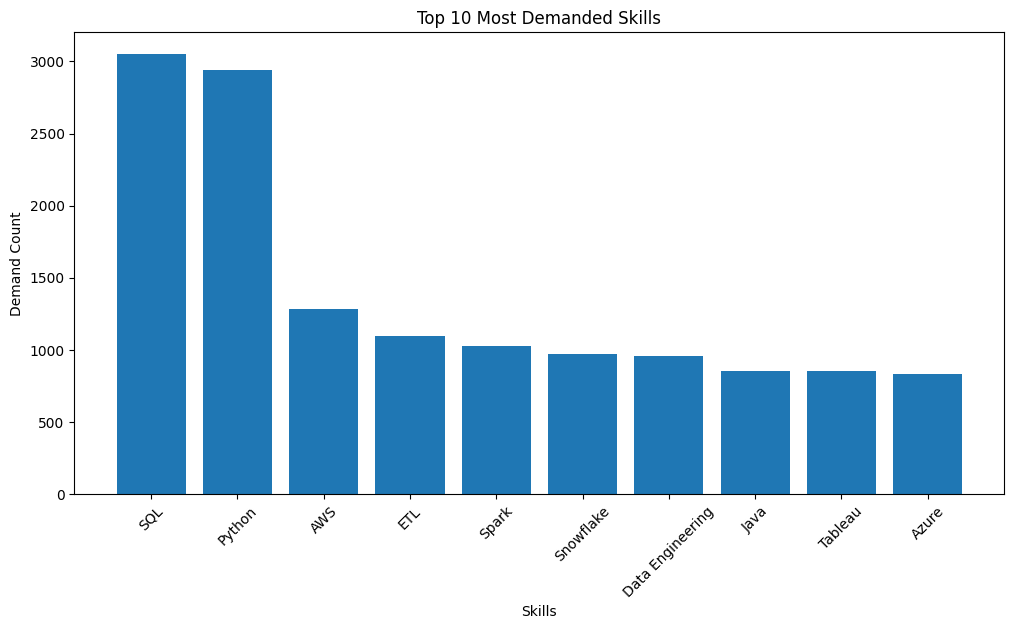

In [23]:
top_10_skills = dict(sorted_skills[:10])

plt.figure(figsize=(12,6))

plt.bar(
    top_10_skills.keys(),
    top_10_skills.values()
)

plt.xticks(rotation=45)

plt.title("Top 10 Most Demanded Skills")

plt.xlabel("Skills")

plt.ylabel("Demand Count")

plt.show()

In [24]:
job_type_counts = df['job_type'].value_counts()

job_type_counts

job_type
Onsite    2817
Hybrid    2061
Remote    1147
Name: count, dtype: int64

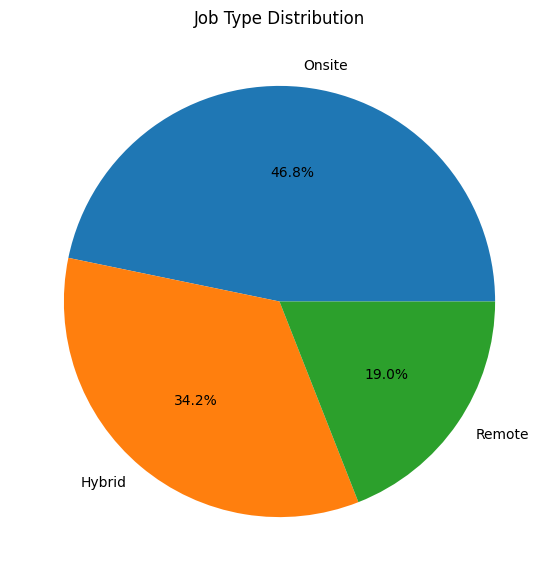

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    job_type_counts,
    labels=job_type_counts.index,
    autopct='%1.1f%%'
)

plt.title("Job Type Distribution")

plt.show()

In [26]:
top_companies = df['company'].value_counts().head(10)

top_companies

company
Recruiting from Scratch      341
Steneral Consulting          112
Nigel Frank International     80
Motion Recruitment            59
Railroad19                    58
Gigster                       51
BDO USA                       50
Crossover                     49
Experfy                       43
DeRisk Technologies           42
Name: count, dtype: int64

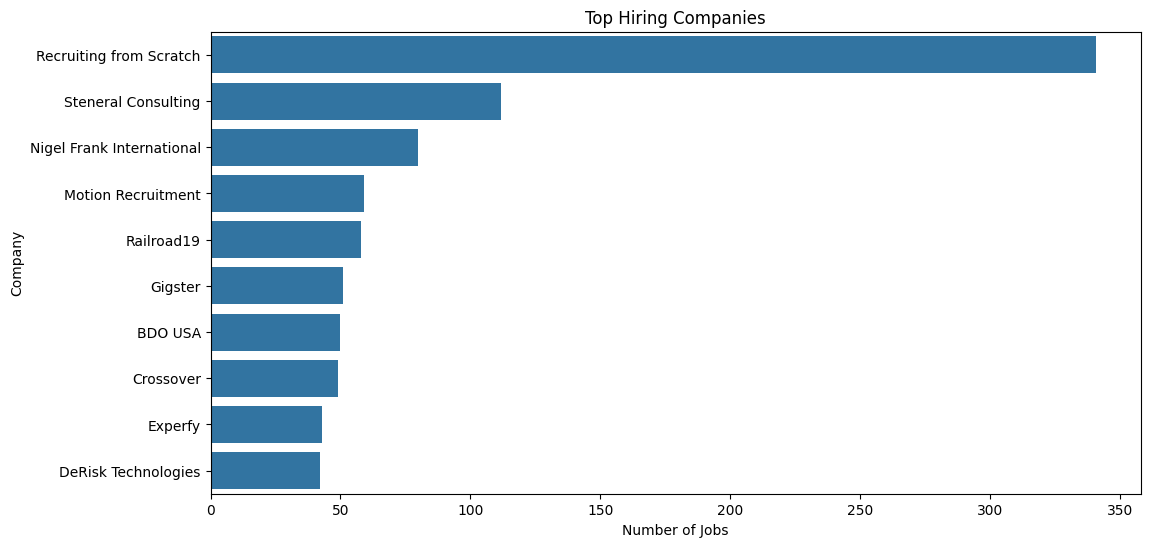

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

plt.title("Top Hiring Companies")

plt.xlabel("Number of Jobs")

plt.ylabel("Company")

plt.show()

In [28]:
top_locations = df['job_location'].value_counts().head(10)

top_locations

job_location
United States                      204
New York, NY                       137
Chicago, IL                        113
London, England, United Kingdom    111
Toronto, Ontario, Canada            94
Atlanta, GA                         87
San Francisco, CA                   78
Phoenix, AZ                         70
Los Angeles, CA                     66
Boston, MA                          64
Name: count, dtype: int64

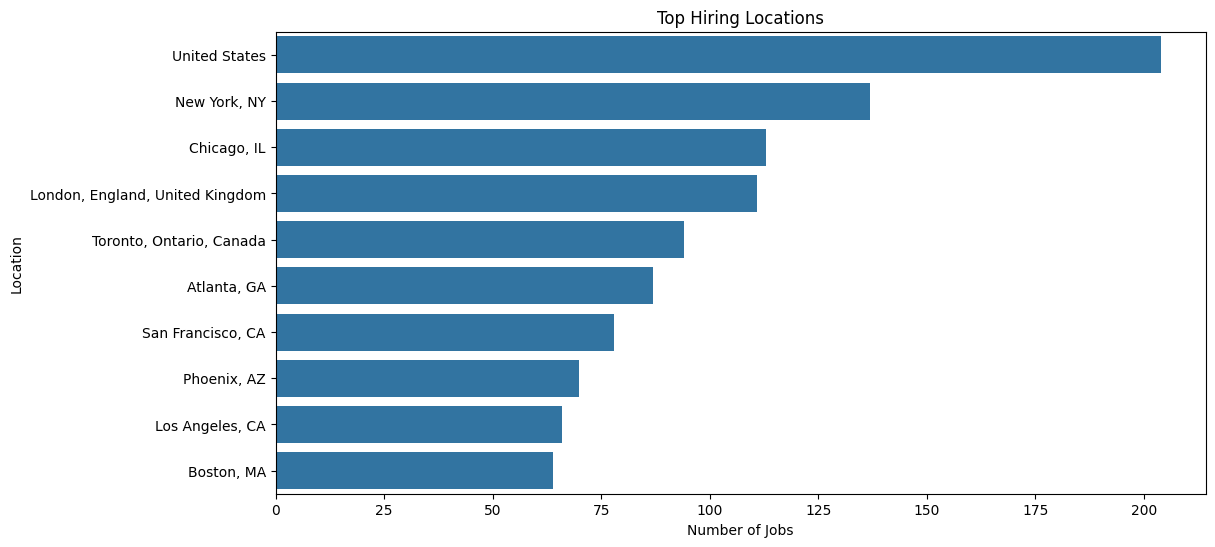

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top Hiring Locations")

plt.xlabel("Number of Jobs")

plt.ylabel("Location")

plt.show()

In [30]:
country_counts = df['search_country'].value_counts()

country_counts

search_country
United States      4031
 Canada             929
 United Kingdom     777
 Australia          288
Name: count, dtype: int64

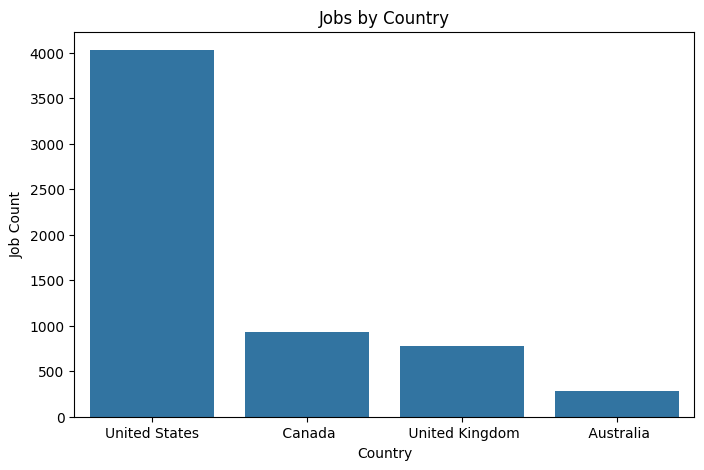

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Jobs by Country")

plt.xlabel("Country")

plt.ylabel("Job Count")

plt.show()

In [32]:
job_level_counts = df['job level'].value_counts()

job_level_counts

job level
Mid senior    5076
Associate      949
Name: count, dtype: int64

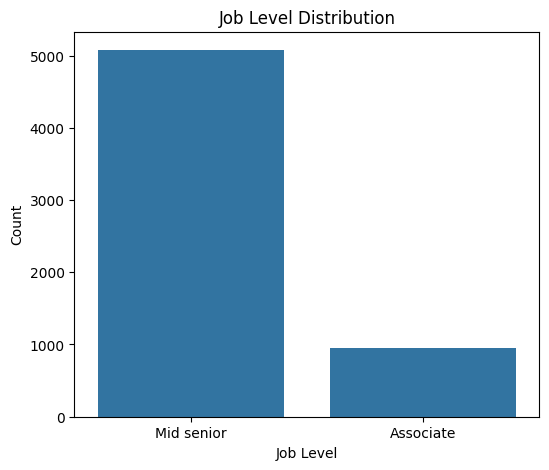

In [33]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=job_level_counts.index,
    y=job_level_counts.values
)

plt.title("Job Level Distribution")

plt.xlabel("Job Level")

plt.ylabel("Count")

plt.show()

In [34]:
df.to_csv("../data/cleaned_jobs.csv", index=False)

In [35]:
import mysql.connector

In [36]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="job_market"
)

print("Connected Successfully")

Connected Successfully


In [37]:
df.rename(columns={'job level': 'job_level'}, inplace=True)

In [38]:
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job_level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [39]:
cursor = conn.cursor()

In [40]:
insert_query = """
INSERT INTO jobs (
    job_title,
    company,
    job_location,
    first_seen,
    search_city,
    search_country,
    job_level,
    job_type,
    job_summary,
    job_skills
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

In [41]:
for i, row in df.iterrows():
    
    values = (
        row['job_title'],
        row['company'],
        row['job_location'],
        row['first_seen'],
        row['search_city'],
        row['search_country'],
        row['job_level'],
        row['job_type'],
        row['job_summary'],
        row['job_skills']
    )
    
    cursor.execute(insert_query, values)

conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


In [42]:
df.to_csv("../data/cleaned_jobs.csv", index=False)

In [43]:
import pandas as pd

top_skills = pd.DataFrame(
    sorted_skills[:10],
    columns=['Skill', 'Demand']
)

top_skills

,Skill,Demand
0,SQL,3050
1,Python,2937
2,AWS,1285
3,ETL,1099
4,Spark,1027
5,Snowflake,973
6,Data Engineering,956
7,Java,855
8,Tableau,855
9,Azure,830


In [44]:
top_skills.to_csv("../data/top_skills.csv", index=False)